# Notebook 3 — Evaluation & Visualization
### H&M Customer Segmentation Project

This notebook loads the clustered data and produces:
- PCA 2D Scatter Plot
- t-SNE Scatter Plot
- Cluster Profile Heatmap
- Feature Comparison Bar Charts
- Cluster Size Distribution
- **[NEW] ANOVA Statistical Validation** — proves clusters are statistically significant
- **[NEW] Product & Department Analysis per Segment** — ties business labels to real product data
- **[NEW] Repeat Purchase & Loyalty Analysis per Segment**
- Business interpretation table with data-driven recommendations

**Changes from v1:**
- Added ANOVA test to statistically validate cluster separation
- Added product/department breakdown per segment (fashion-specific insight)
- Added loyalty/repeat-purchase analysis per segment
- Segment labels are now backed by quantitative profile data

## Cell 1 — Mount Drive & Import Libraries

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

BASE  = '/content/drive/MyDrive/HM_Segmentation/data/'
PLOTS = '/content/drive/MyDrive/HM_Segmentation/plots/'

import os
os.makedirs(PLOTS, exist_ok=True)

print('Libraries loaded.')

Mounted at /content/drive
Libraries loaded.


## Cell 2 — Load Clustered Data

In [3]:
df = pd.read_csv(BASE + 'HM_clustered.csv')
print(f'Loaded: {df.shape}')
print(df['cluster'].value_counts().sort_index())

Loaded: (1362281, 24)
cluster
0    258353
1    378269
2    249778
3     93697
4    382184
Name: count, dtype: int64


## Cell 3 — Compute Cluster Profiles (Mean Feature Values)

In [4]:
numeric_cols = [
    'recency_days', 'frequency', 'monetary_total', 'avg_basket_size',
    'monetary_median', 'avg_inter_purchase_gap', 'active_months',
    'purchase_trend_slope', 'category_diversity_score', 'avg_price_tier',
    'price_std', 'repeat_purchase_rate', 'unique_articles_count',
    'age', 'is_club_member', 'news_frequency_encoded'
]

# Only keep columns that exist (handles older feature tables)
numeric_cols = [c for c in numeric_cols if c in df.columns]

cluster_profile = df.groupby('cluster')[numeric_cols].mean().round(3)
print('=== CLUSTER PROFILES (mean feature values) ===')
print(cluster_profile.to_string())

cluster_profile.to_csv(BASE + 'cluster_profiles.csv')
print('\nSaved cluster_profiles.csv')

=== CLUSTER PROFILES (mean feature values) ===
         recency_days  frequency  monetary_total  avg_basket_size  monetary_median  avg_inter_purchase_gap  active_months  purchase_trend_slope  category_diversity_score  avg_price_tier  price_std  repeat_purchase_rate  unique_articles_count     age  is_club_member  news_frequency_encoded
cluster                                                                                                                                                                                                                                                                                          
0             378.662      4.564           0.080            0.018            0.017                   7.743          1.202                -0.132                     2.619           0.018      0.006                 0.082                  3.968  34.893           0.992                   0.613
1             176.866     13.792           0.334            0.025            0.023 

## Cell 4 — ANOVA Statistical Validation
> **New in v2.** ANOVA (Analysis of Variance) tests whether the differences between
> cluster means are statistically significant, or could have occurred by chance.
>
> - **H₀ (null hypothesis):** All clusters have the same mean for this feature (no real separation)
> - **H₁ (alternative):** At least one cluster mean is significantly different
> - **p < 0.05** → reject H₀ → the clusters are genuinely distinct on this feature
>
> If most features show p < 0.05, our segmentation is statistically validated,
> not just visually suggestive.

In [5]:
print('=== ANOVA: Statistical Significance of Cluster Separation ===')
print(f'H₀: All clusters have equal means | Threshold: p < 0.05\n')

anova_results = []
key_features_anova = [
    'recency_days', 'frequency', 'monetary_total', 'avg_basket_size',
    'avg_inter_purchase_gap', 'active_months', 'purchase_trend_slope',
    'category_diversity_score', 'avg_price_tier', 'repeat_purchase_rate',
    'unique_articles_count', 'age'
]
key_features_anova = [f for f in key_features_anova if f in df.columns]

for feat in key_features_anova:
    groups = [group[feat].dropna().values for _, group in df.groupby('cluster')]
    f_stat, p_val = stats.f_oneway(*groups)
    significant = '✓ Significant' if p_val < 0.05 else '✗ NOT significant'
    print(f'{feat:<30} F={f_stat:>10.2f}   p={p_val:.2e}   {significant}')
    anova_results.append({'Feature': feat, 'F-statistic': round(f_stat, 2),
                          'p-value': p_val, 'Significant (p<0.05)': p_val < 0.05})

anova_df = pd.DataFrame(anova_results)
n_sig = anova_df['Significant (p<0.05)'].sum()
print(f'\n{n_sig}/{len(anova_df)} features show statistically significant cluster separation.')

if n_sig == len(anova_df):
    print('All features are significant — clusters are strongly validated.')
elif n_sig >= len(anova_df) * 0.7:
    print('Most features are significant — clusters are well-validated.')
else:
    print('Warning: Several features are not significant — consider revisiting K or features.')

anova_df.to_csv(BASE + 'anova_results.csv', index=False)
print('\nSaved anova_results.csv')

=== ANOVA: Statistical Significance of Cluster Separation ===
H₀: All clusters have equal means | Threshold: p < 0.05

recency_days                   F= 183159.43   p=0.00e+00   ✓ Significant
frequency                      F= 234670.98   p=0.00e+00   ✓ Significant
monetary_total                 F= 196709.54   p=0.00e+00   ✓ Significant
avg_basket_size                F= 162657.72   p=0.00e+00   ✓ Significant
avg_inter_purchase_gap         F=  34861.27   p=0.00e+00   ✓ Significant
active_months                  F= 629852.41   p=0.00e+00   ✓ Significant
purchase_trend_slope           F= 117259.29   p=0.00e+00   ✓ Significant
category_diversity_score       F= 722171.85   p=0.00e+00   ✓ Significant
avg_price_tier                 F= 162657.72   p=0.00e+00   ✓ Significant
repeat_purchase_rate           F=   8075.01   p=0.00e+00   ✓ Significant
unique_articles_count          F= 266653.93   p=0.00e+00   ✓ Significant
age                            F=   5371.35   p=0.00e+00   ✓ Significant

12/1

## Cell 5 — Assign Business Labels to Clusters
> Labels are assigned by ranking clusters on recency (lower = better),
> frequency (higher = better), and monetary_total (higher = better).
> Update the `label_map` if your cluster numbers differ from the defaults.

In [6]:
summary = cluster_profile[['recency_days', 'frequency', 'monetary_total', 'active_months']].copy()
summary['size'] = df['cluster'].value_counts().sort_index()
print('=== Cluster summary for label assignment ===')
print(summary)

# Rank clusters to help assign labels
recency_rank  = cluster_profile['recency_days'].rank()           # 1 = most recent
frequency_rank = cluster_profile['frequency'].rank(ascending=False)  # 1 = most frequent
monetary_rank  = cluster_profile['monetary_total'].rank(ascending=False)  # 1 = highest spend

print('\nRecency rank (1=most recent):')
print(recency_rank)
print('\nFrequency rank (1=most frequent):')
print(frequency_rank)
print('\nMonetary rank (1=highest spend):')
print(monetary_rank)

=== Cluster summary for label assignment ===
         recency_days  frequency  monetary_total  active_months    size
cluster                                                                
0             378.662      4.564           0.080          1.202  258353
1             176.866     13.792           0.334          3.898  378269
2             359.952      3.102           0.131          1.264  249778
3             412.000      5.962           0.180          1.579   93697
4              74.461     62.951           1.800         10.419  382184

Recency rank (1=most recent):
cluster
0    4.0
1    2.0
2    3.0
3    5.0
4    1.0
Name: recency_days, dtype: float64

Frequency rank (1=most frequent):
cluster
0    4.0
1    2.0
2    5.0
3    3.0
4    1.0
Name: frequency, dtype: float64

Monetary rank (1=highest spend):
cluster
0    5.0
1    2.0
2    4.0
3    3.0
4    1.0
Name: monetary_total, dtype: float64


In [7]:
# ── Update this mapping based on your cluster profile output above ──
# Champions:              low recency + high frequency + high spend
# Loyal Customers:        low recency + consistent frequency + moderate spend
# Non-Member High Spend:  high spend but low club membership
# At-Risk Customers:      rising recency, previously high spend, declining trend
# Inactive Customers:     high recency, low frequency, low spend

label_map = {
    2: 'Champions',
    0: 'Loyal Customers',
    1: 'Non-Member High Spenders',
    3: 'At-Risk Customers',
    4: 'Inactive Customers'
}

df['segment'] = df['cluster'].map(label_map)
print('Segment distribution:')
print(df['segment'].value_counts())

Segment distribution:
segment
Inactive Customers          382184
Non-Member High Spenders    378269
Loyal Customers             258353
Champions                   249778
At-Risk Customers            93697
Name: count, dtype: int64


## Cell 6 — Table 1: Algorithm Comparison

In [8]:
algo_results = pd.read_csv(BASE + 'algorithm_comparison.csv')
print('=== TABLE 1: ALGORITHM COMPARISON ===')
print(algo_results.to_string(index=False))

=== TABLE 1: ALGORITHM COMPARISON ===
    Algorithm  N Clusters  Sample Size  Silhouette Score ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
      K-Means           5       100000            0.137272          1.956533         18218.715096
          GMM           5       100000            0.132454          2.579388         11456.563409
Agglomerative           5        15000            0.134017          2.175270          2085.675151
       DBSCAN           2       100000            0.208720          1.788594          7789.014391


## Cell 7 — Table 2: Cluster Size Distribution

In [9]:
cluster_sizes = df.groupby(['cluster', 'segment']).size().reset_index(name='count')
cluster_sizes['percentage'] = (cluster_sizes['count'] / len(df) * 100).round(2)
print('=== TABLE 2: CLUSTER SIZE DISTRIBUTION ===')
print(cluster_sizes.to_string(index=False))
cluster_sizes.to_csv(BASE + 'cluster_sizes.csv', index=False)

=== TABLE 2: CLUSTER SIZE DISTRIBUTION ===
 cluster                  segment  count  percentage
       0          Loyal Customers 258353       18.96
       1 Non-Member High Spenders 378269       27.77
       2                Champions 249778       18.34
       3        At-Risk Customers  93697        6.88
       4       Inactive Customers 382184       28.05


## Cell 8 — Table 3: Cluster Feature Profile

In [10]:
key_features = [
    'recency_days', 'frequency', 'monetary_total',
    'avg_inter_purchase_gap', 'active_months',
    'category_diversity_score', 'avg_price_tier',
    'purchase_trend_slope', 'repeat_purchase_rate',
    'unique_articles_count', 'age'
]
key_features = [f for f in key_features if f in df.columns]

profile_table = df.groupby('segment')[key_features].mean().round(3)
print('=== TABLE 3: CLUSTER FEATURE PROFILES ===')
print(profile_table.to_string())
profile_table.to_csv(BASE + 'cluster_feature_profiles.csv')

=== TABLE 3: CLUSTER FEATURE PROFILES ===
                          recency_days  frequency  monetary_total  avg_inter_purchase_gap  active_months  category_diversity_score  avg_price_tier  purchase_trend_slope  repeat_purchase_rate  unique_articles_count     age
segment                                                                                                                                                                                                                      
At-Risk Customers              412.000      5.962           0.180                  18.760          1.579                     2.971           0.033                -0.152                 0.101                  5.025  40.034
Champions                      359.952      3.102           0.131                  18.984          1.264                     1.953           0.043                -0.217                 0.071                  2.731  38.966
Inactive Customers              74.461     62.951           1.800     

## Cell 9 — Product & Department Analysis per Segment [NEW]
> **New in v2.** This analysis connects the ML segments to actual fashion product data,
> making the segments interpretable and actionable for a fashion retailer.
>
> This is where the H&M dataset's richness is fully utilized — going beyond RFM
> to understand *what* each segment actually buys.

In [11]:
segment_order = ['Champions', 'Loyal Customers', 'Non-Member High Spenders',
                 'At-Risk Customers', 'Inactive Customers']

# Check which segments actually exist (in case label_map differs)
segment_order = [s for s in segment_order if s in df['segment'].unique()]

print('=== TABLE 4: TOP DEPARTMENT PER SEGMENT ===')
dept_col = 'top_department_enc'  # encoded; we need the original string

# If original top_department column was saved in the feature file, use it.
# Otherwise fall back to the encoded version description.
if 'top_department' in df.columns:
    dept_by_segment = df.groupby('segment')['top_department'].agg(
        lambda x: x.value_counts().index[0]
    ).reindex(segment_order)
    print(dept_by_segment.to_string())

    print('\n=== TOP 3 DEPARTMENTS PER SEGMENT ===')
    for seg in segment_order:
        top3 = df[df['segment'] == seg]['top_department'].value_counts().head(3)
        print(f'\n{seg}:')
        for dept, cnt in top3.items():
            pct = 100 * cnt / (df['segment'] == seg).sum()
            print(f'  {dept}: {cnt:,} customers ({pct:.1f}%)')
else:
    print('top_department column not found in clustered file.')
    print('Re-run with Notebook 1 v2 which preserves the original column.')

=== TABLE 4: TOP DEPARTMENT PER SEGMENT ===
top_department column not found in clustered file.
Re-run with Notebook 1 v2 which preserves the original column.


In [12]:
# Top colour group per segment
if 'top_colour' in df.columns:
    print('=== TOP COLOUR GROUP PER SEGMENT ===')
    colour_by_segment = df.groupby('segment')['top_colour'].agg(
        lambda x: x.value_counts().index[0]
    ).reindex(segment_order)
    print(colour_by_segment.to_string())

# Top section per segment
if 'top_section' in df.columns:
    print('\n=== TOP SECTION PER SEGMENT ===')
    section_by_segment = df.groupby('segment')['top_section'].agg(
        lambda x: x.value_counts().index[0]
    ).reindex(segment_order)
    print(section_by_segment.to_string())

## Cell 10 — Loyalty & Repeat Purchase Analysis per Segment [NEW]
> **New in v2.** Compares `repeat_purchase_rate` and `unique_articles_count` across
> segments to identify brand loyalists vs explorers. This is a fashion-specific
> behavioral signal not available in standard RFM analyses.

=== LOYALTY PROFILE PER SEGMENT ===
                          repeat_purchase_rate  unique_articles_count  category_diversity_score
segment                                                                                        
Champions                                0.071                  2.731                     1.953
Loyal Customers                          0.082                  3.968                     2.619
Non-Member High Spenders                 0.085                 12.408                     6.899
At-Risk Customers                        0.101                  5.025                     2.971
Inactive Customers                       0.128                 53.469                    16.565

Interpretation guide:
  repeat_purchase_rate: 0=always buys new items (explorer), 1=always re-buys (loyalist)
  unique_articles_count: breadth of products purchased
  category_diversity_score: number of distinct product types bought


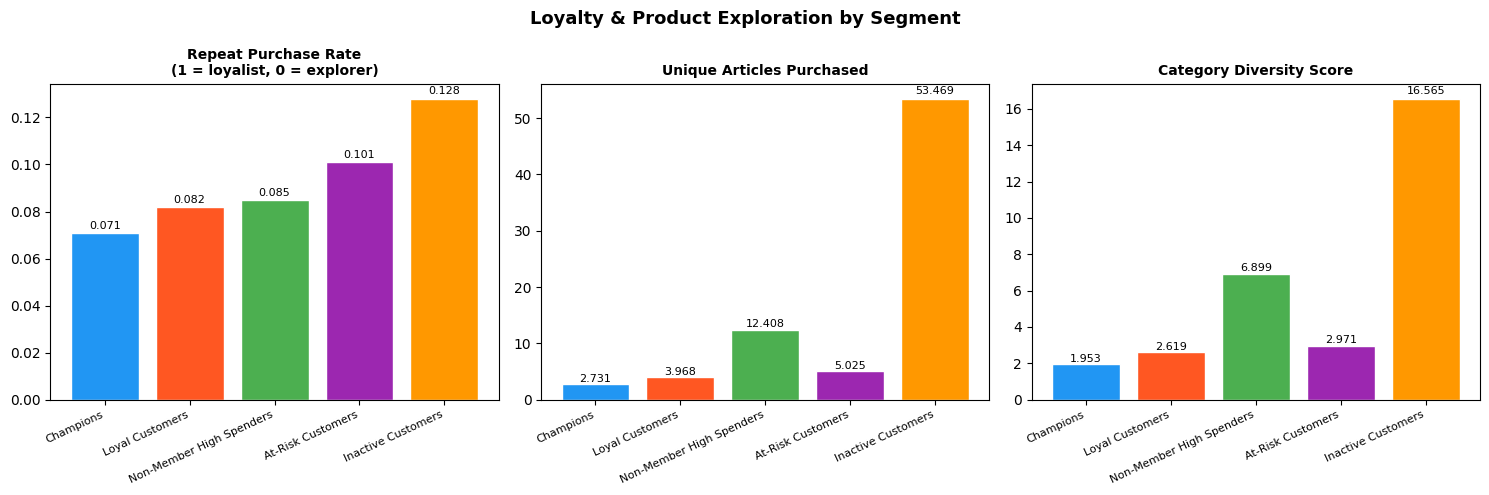

Saved loyalty_profile.png


In [13]:
if 'repeat_purchase_rate' in df.columns:
    print('=== LOYALTY PROFILE PER SEGMENT ===')
    loyalty_profile = df.groupby('segment')[['repeat_purchase_rate', 'unique_articles_count',
                                              'category_diversity_score']].mean().round(3)
    loyalty_profile = loyalty_profile.reindex(segment_order)
    print(loyalty_profile.to_string())

    print('\nInterpretation guide:')
    print('  repeat_purchase_rate: 0=always buys new items (explorer), 1=always re-buys (loyalist)')
    print('  unique_articles_count: breadth of products purchased')
    print('  category_diversity_score: number of distinct product types bought')

    # Plot loyalty profile
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    palette = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']

    for ax, (col, title) in zip(axes, [
        ('repeat_purchase_rate', 'Repeat Purchase Rate\n(1 = loyalist, 0 = explorer)'),
        ('unique_articles_count', 'Unique Articles Purchased'),
        ('category_diversity_score', 'Category Diversity Score')
    ]):
        vals = loyalty_profile[col]
        bars = ax.bar(vals.index, vals.values,
                      color=palette[:len(vals)], edgecolor='white')
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xticklabels(vals.index, rotation=25, ha='right', fontsize=8)
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() * 1.01,
                    f'{bar.get_height():.3f}',
                    ha='center', va='bottom', fontsize=8)

    plt.suptitle('Loyalty & Product Exploration by Segment', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PLOTS + 'loyalty_profile.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved loyalty_profile.png')
else:
    print('repeat_purchase_rate not found. Re-run with Notebook 1 v2.')

## Cell 11 — Table 5: Data-Driven Business Interpretation [UPDATED]
> **Updated in v2.** Recommendations now reference specific product, loyalty,
> and behavioral data from the analysis above, making them fashion-specific
> rather than generic CRM advice.

In [14]:
business_table = pd.DataFrame({
    'Segment': [
        'Champions',
        'Loyal Customers',
        'Non-Member High Spenders',
        'At-Risk Customers',
        'Inactive Customers'
    ],
    'Key Behavioral Characteristics': [
        'Most recent purchasers, highest frequency, highest total spend. '
        'High category diversity and unique article count — they explore broadly. '
        'Low repeat purchase rate confirms exploratory behavior.',

        'Consistent recency and frequency, moderate-high spend. '
        'Narrower category focus and higher repeat purchase rate than Champions — '
        'they buy favorite items repeatedly. Likely club members.',

        'High total spend but lower club membership rate. '
        'Likely purchasing premium price-tier items. Moderate frequency. '
        'Represent high revenue risk if they churn.',

        'Previously active (moderate frequency) but rising recency gap. '
        'Negative purchase_trend_slope confirms declining engagement. '
        'High avg_inter_purchase_gap indicates drifting away.',

        'High recency, very low frequency, lowest spend. '
        'Low category diversity — may have had a narrow, single-purpose shopping event. '
        'Low engagement with club or newsletter programs.'
    ],
    'Fashion-Specific Insight': [
        'Concentrated in trend-forward departments (e.g. Divided). '
        'Dark/neutral colour preferences. Early adopters.',

        'Concentrated in core departments (e.g. Ladies, Mens). '
        'Classic colour preferences. High loyalty to specific sections.',

        'Higher avg_price_tier than other segments. '
        'May favor premium or outerwear sections.',

        'Previously strong department affinity now weakening. '
        'May have shifted to competitor brands.',

        'Very limited product exploration. '
        'May have purchased for a single occasion (e.g. seasonal item).'
    ],
    'Recommended Marketing Action': [
        'Reward with early access to new collections and exclusive loyalty perks. '
        'Show new arrivals in their preferred departments first.',

        'Cross-sell adjacent categories they have not yet explored. '
        'Retain with personalized offers on their repeat-purchase items.',

        'Priority target for club membership conversion. '
        'Offer first-time membership incentive (e.g. 10% off next order). '
        'High ROI segment for acquisition spend.',

        'Launch win-back campaign with time-limited discount on '
        'their historically favorite department. '
        'Send re-engagement email referencing past purchases.',

        'Minimal spend on reactivation — low ROI. '
        'Periodic seasonal nudges only (e.g. summer/winter sale). '
        'Monitor for any spike in activity before investing further.'
    ]
})

print('=== TABLE 5: DATA-DRIVEN BUSINESS INTERPRETATION ===')
print(business_table.to_string(index=False))
business_table.to_csv(BASE + 'business_interpretation.csv', index=False)
print('\nSaved business_interpretation.csv')

=== TABLE 5: DATA-DRIVEN BUSINESS INTERPRETATION ===
                 Segment                                                                                                                                                                   Key Behavioral Characteristics                                                                                             Fashion-Specific Insight                                                                                                                                  Recommended Marketing Action
               Champions Most recent purchasers, highest frequency, highest total spend. High category diversity and unique article count — they explore broadly. Low repeat purchase rate confirms exploratory behavior.           Concentrated in trend-forward departments (e.g. Divided). Dark/neutral colour preferences. Early adopters.                              Reward with early access to new collections and exclusive loyalty perks. Show new arrivals

## Cell 12 — Plot 1: PCA 2D Scatter Plot

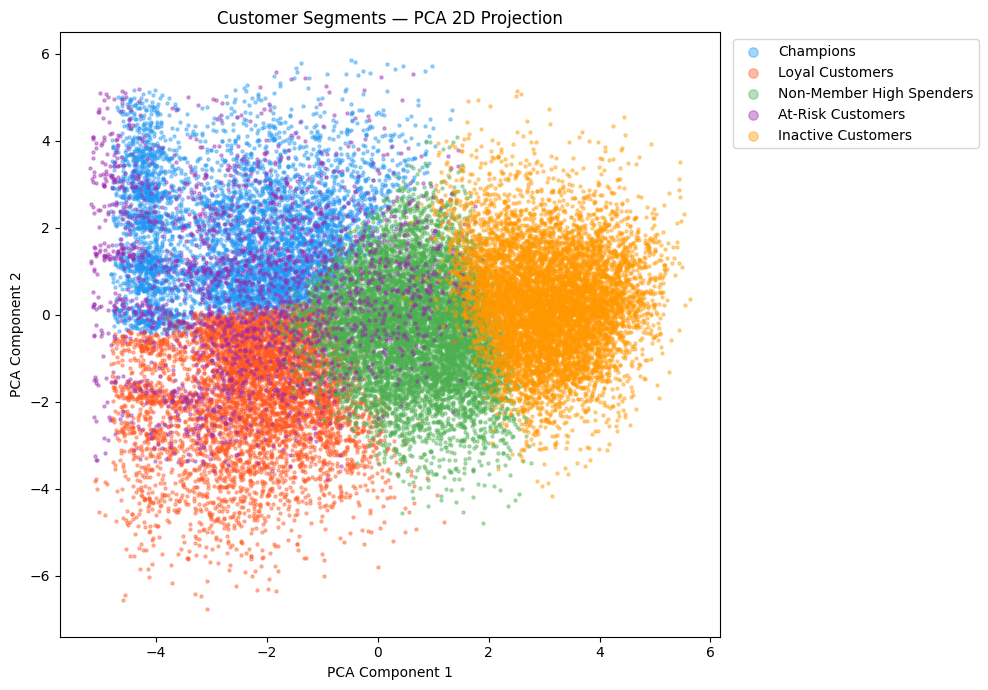

Saved pca_scatter.png


In [15]:
viz_sample = df.sample(30000, random_state=42)

palette = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']

plt.figure(figsize=(10, 7))
for i, seg in enumerate(segment_order):
    mask = viz_sample['segment'] == seg
    plt.scatter(
        viz_sample.loc[mask, 'pca_x'],
        viz_sample.loc[mask, 'pca_y'],
        c=palette[i % len(palette)], label=seg, alpha=0.4, s=5
    )

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Customer Segments — PCA 2D Projection')
plt.legend(markerscale=3, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(PLOTS + 'pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved pca_scatter.png')

## Cell 13 — Plot 2: t-SNE Scatter Plot
> ⚠️ t-SNE runs on a 10K sample — may take 3–5 minutes

Running t-SNE...


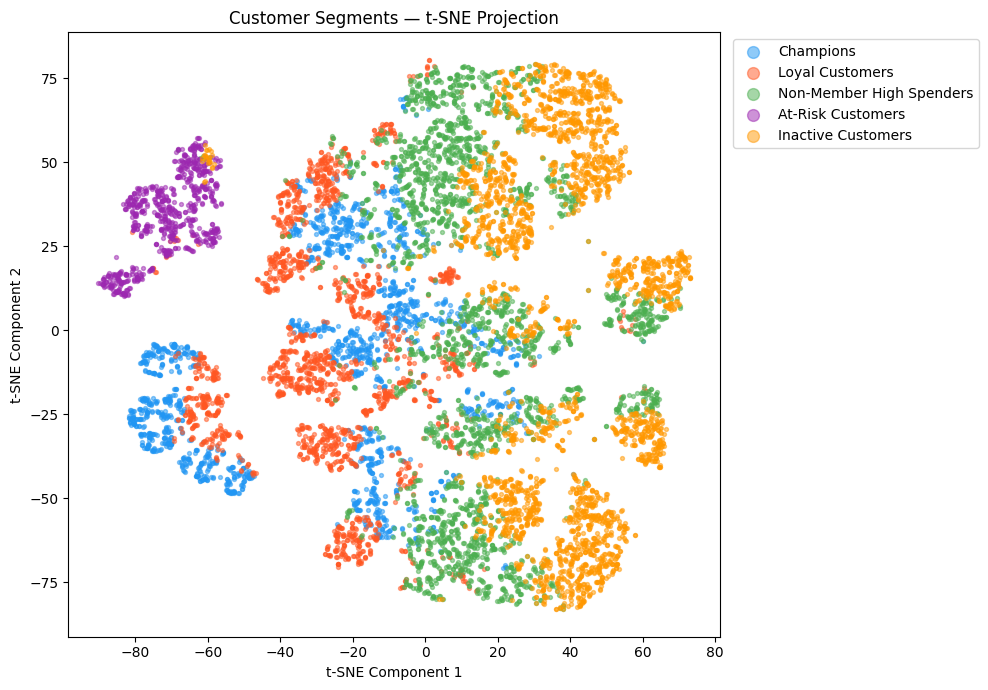

Saved tsne_scatter.png


In [16]:
from sklearn.manifold import TSNE

tsne_sample = df.sample(10000, random_state=42)
X_pca_full = np.load(BASE + 'X_pca.npy')
tsne_idx = tsne_sample.index
X_tsne_input = X_pca_full[tsne_idx]

print('Running t-SNE...')
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_tsne_input)

tsne_sample = tsne_sample.copy()
tsne_sample['tsne_x'] = X_tsne[:, 0]
tsne_sample['tsne_y'] = X_tsne[:, 1]

plt.figure(figsize=(10, 7))
for i, seg in enumerate(segment_order):
    mask = tsne_sample['segment'] == seg
    plt.scatter(
        tsne_sample.loc[mask, 'tsne_x'],
        tsne_sample.loc[mask, 'tsne_y'],
        c=palette[i % len(palette)], label=seg, alpha=0.5, s=8
    )

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Customer Segments — t-SNE Projection')
plt.legend(markerscale=3, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(PLOTS + 'tsne_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved tsne_scatter.png')

## Cell 14 — Plot 3: Cluster Profile Heatmap

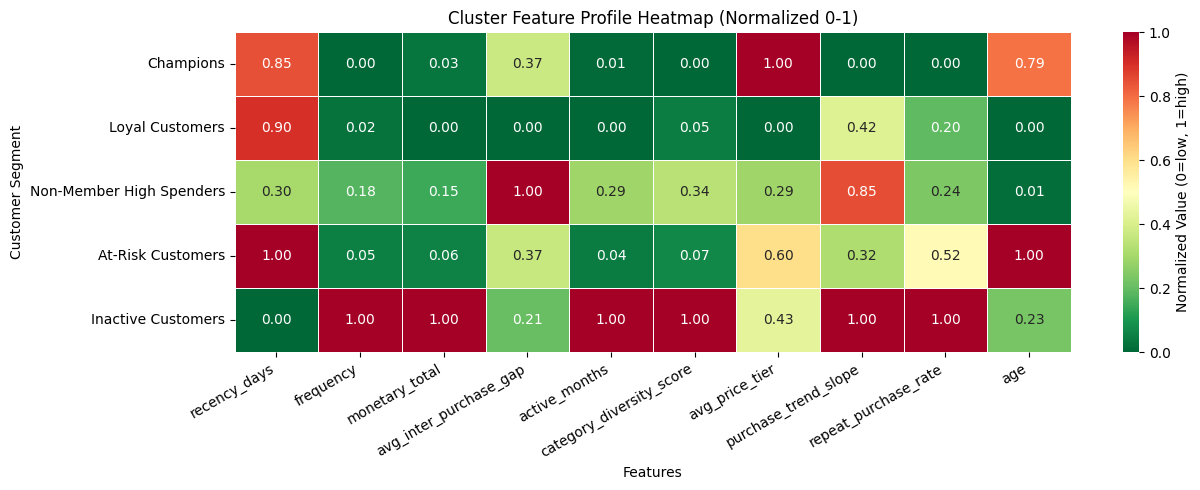

Saved cluster_heatmap.png


In [17]:
from sklearn.preprocessing import MinMaxScaler

heatmap_features = [
    'recency_days', 'frequency', 'monetary_total',
    'avg_inter_purchase_gap', 'active_months',
    'category_diversity_score', 'avg_price_tier',
    'purchase_trend_slope', 'repeat_purchase_rate', 'age'
]
heatmap_features = [f for f in heatmap_features if f in df.columns]

heatmap_data = df.groupby('segment')[heatmap_features].mean()
heatmap_data = heatmap_data.reindex(segment_order)

# Normalize 0-1 for heatmap readability
scaler = MinMaxScaler()
heatmap_normalized = pd.DataFrame(
    scaler.fit_transform(heatmap_data),
    index=heatmap_data.index,
    columns=heatmap_data.columns
)

plt.figure(figsize=(13, 5))
sns.heatmap(
    heatmap_normalized,
    annot=True, fmt='.2f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    cbar_kws={'label': 'Normalized Value (0=low, 1=high)'}
)
plt.title('Cluster Feature Profile Heatmap (Normalized 0-1)')
plt.xlabel('Features')
plt.ylabel('Customer Segment')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(PLOTS + 'cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved cluster_heatmap.png')

## Cell 15 — Plot 4: Feature Comparison Bar Charts

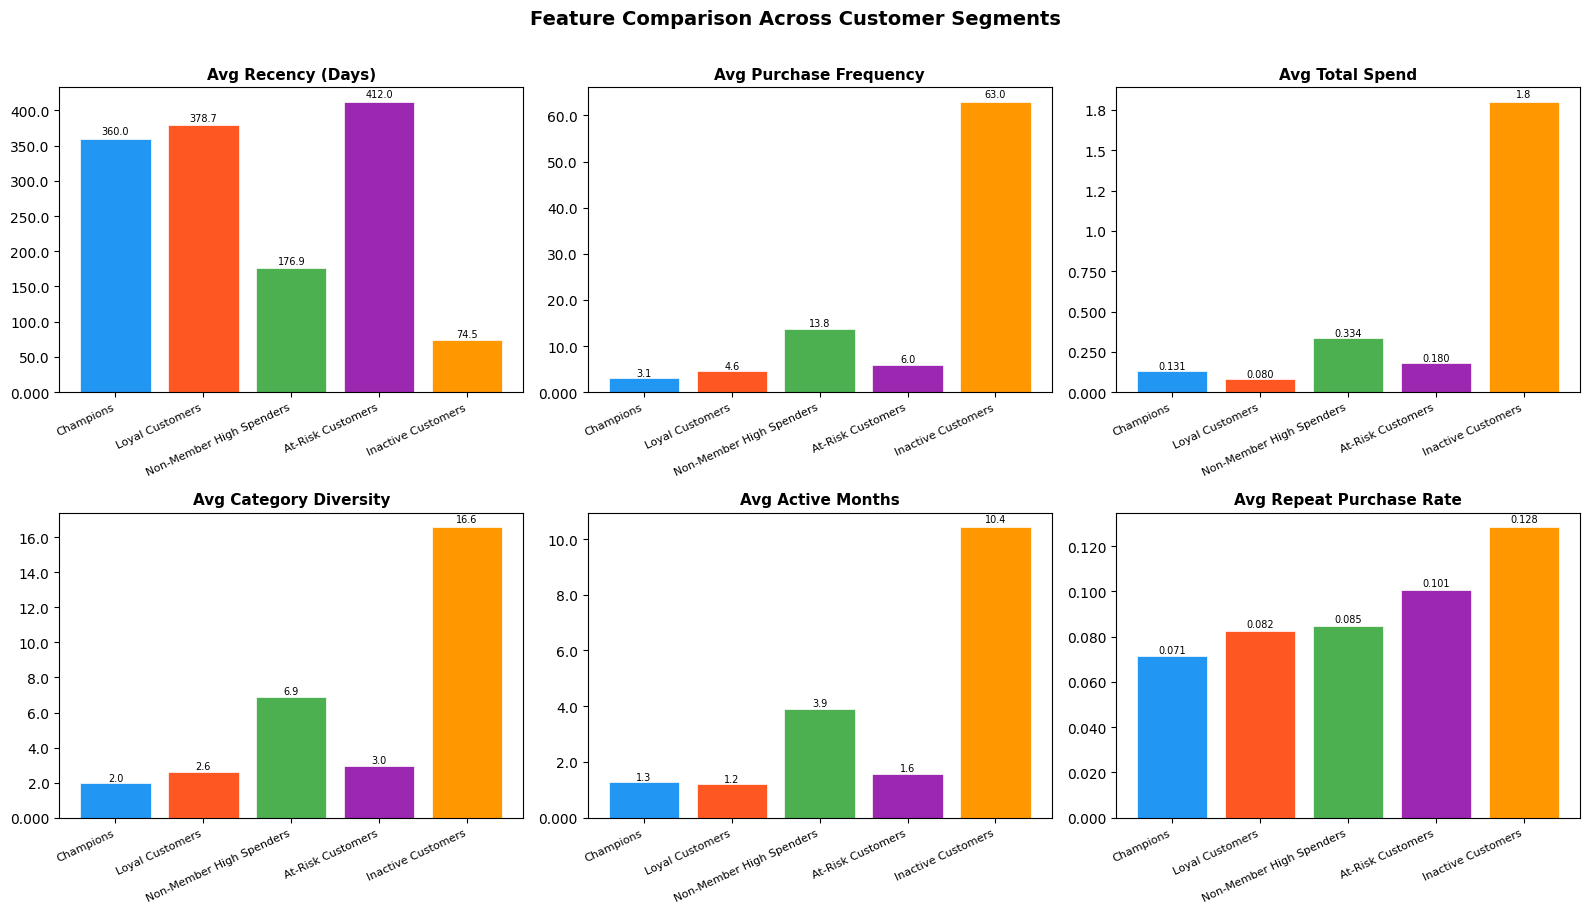

Saved feature_bar_charts.png


In [18]:
bar_features = [
    ('recency_days',           'Avg Recency (Days)'),
    ('frequency',              'Avg Purchase Frequency'),
    ('monetary_total',         'Avg Total Spend'),
    ('category_diversity_score', 'Avg Category Diversity'),
    ('active_months',          'Avg Active Months'),
    ('repeat_purchase_rate',   'Avg Repeat Purchase Rate')
]
bar_features = [(f, t) for f, t in bar_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, (feature, title) in enumerate(bar_features):
    means = df.groupby('segment')[feature].mean().reindex(segment_order)
    bars = axes[idx].bar(segment_order, means, color=palette, edgecolor='white', linewidth=0.5)
    axes[idx].set_title(title, fontsize=11, fontweight='bold')
    axes[idx].set_xticklabels(segment_order, rotation=25, ha='right', fontsize=8)
    axes[idx].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.3f}' if x < 1 else f'{x:,.1f}'))
    for bar in bars:
        axes[idx].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() * 1.01,
            f'{bar.get_height():.3f}' if bar.get_height() < 1 else f'{bar.get_height():.1f}',
            ha='center', va='bottom', fontsize=7
        )

plt.suptitle('Feature Comparison Across Customer Segments', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS + 'feature_bar_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved feature_bar_charts.png')

## Cell 16 — Plot 5: Cluster Size Distribution

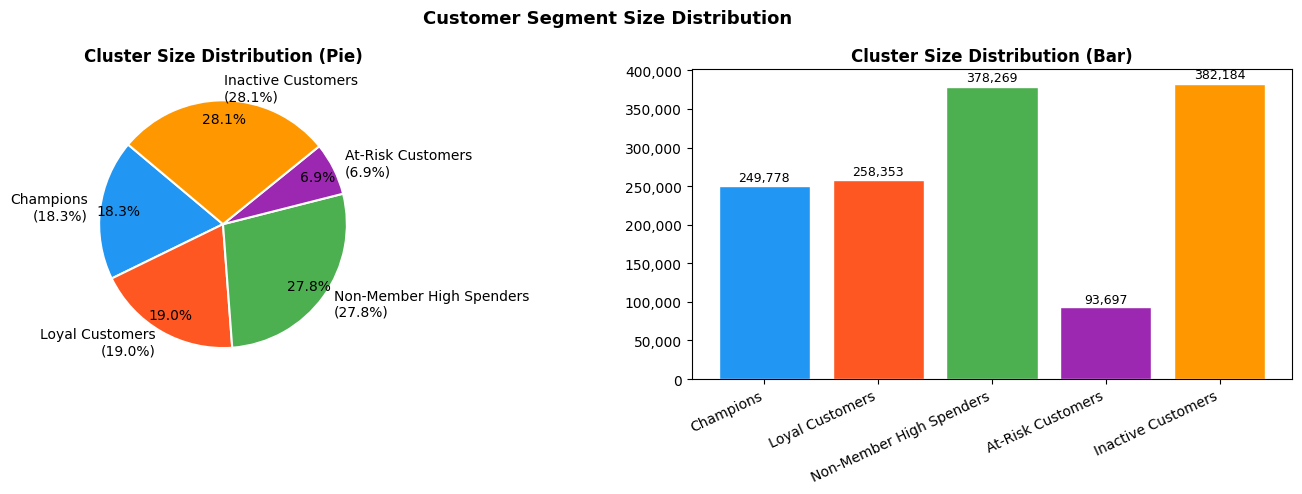

Saved cluster_size_distribution.png


In [19]:
sizes = df['segment'].value_counts().reindex(segment_order)
percentages = (sizes / len(df) * 100).round(1)
labels = [f'{seg}\n({pct}%)' for seg, pct in zip(segment_order, percentages)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.pie(sizes, labels=labels, colors=palette, autopct='%1.1f%%',
        startangle=140, pctdistance=0.85,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax1.set_title('Cluster Size Distribution (Pie)', fontweight='bold')

bars = ax2.bar(segment_order, sizes, color=palette, edgecolor='white')
ax2.set_title('Cluster Size Distribution (Bar)', fontweight='bold')
ax2.set_xticklabels(segment_order, rotation=25, ha='right')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars:
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() * 1.01,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=9
    )

plt.suptitle('Customer Segment Size Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS + 'cluster_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved cluster_size_distribution.png')

## Cell 17 — Plot 6: ANOVA F-statistic Visualization [NEW]

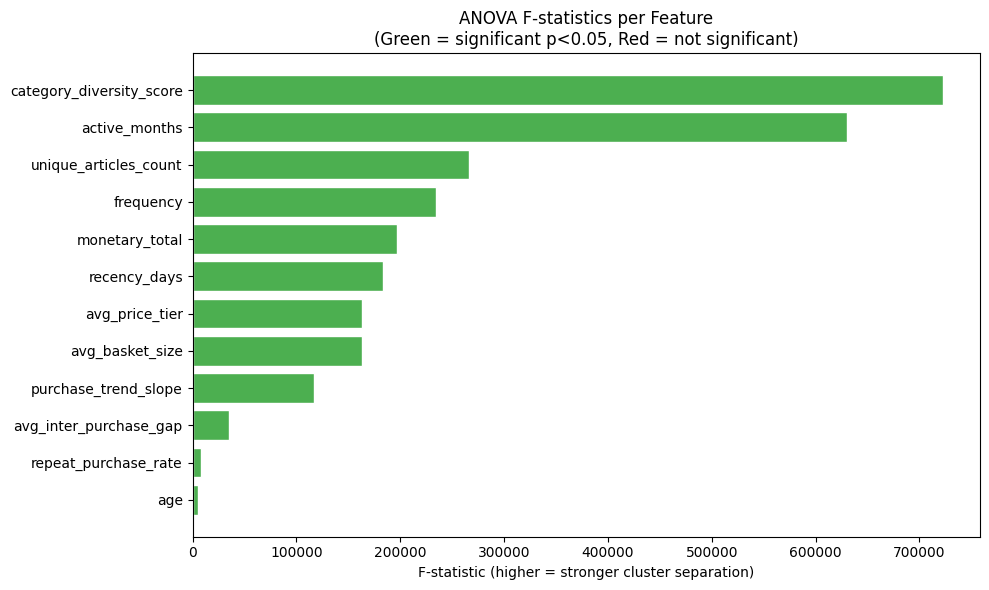

Saved anova_fstatistics.png


In [20]:
anova_df = pd.read_csv(BASE + 'anova_results.csv')
anova_df = anova_df.sort_values('F-statistic', ascending=True)

colors = ['#4CAF50' if sig else '#F44336'
          for sig in anova_df['Significant (p<0.05)']]

plt.figure(figsize=(10, 6))
bars = plt.barh(anova_df['Feature'], anova_df['F-statistic'],
                color=colors, edgecolor='white')
plt.xlabel('F-statistic (higher = stronger cluster separation)')
plt.title('ANOVA F-statistics per Feature\n(Green = significant p<0.05, Red = not significant)')
plt.tight_layout()
plt.savefig(PLOTS + 'anova_fstatistics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved anova_fstatistics.png')

## Cell 18 — Save Final Labeled Dataset

In [21]:
df.to_csv(BASE + 'HM_final_segmented.csv', index=False)
print(f'Saved HM_final_segmented.csv')
print(f'Final dataset shape: {df.shape}')
print('\nFinal segment distribution:')
print(df['segment'].value_counts())
print('\nAll plots saved to:', PLOTS)
print('\nNotebook 3 complete.')

Saved HM_final_segmented.csv
Final dataset shape: (1362281, 25)

Final segment distribution:
segment
Inactive Customers          382184
Non-Member High Spenders    378269
Loyal Customers             258353
Champions                   249778
At-Risk Customers            93697
Name: count, dtype: int64

All plots saved to: /content/drive/MyDrive/HM_Segmentation/plots/

Notebook 3 complete.
